# Self-Attention e Transformers

## Do vetor de entrada à inferência autoregressiva

Nesta aula vamos construir, **do zero em PyTorch**, os principais componentes de um Transformer e observar visualmente o que acontece em cada etapa.

A proposta é sair de uma matriz de embeddings e chegar a um modelo capaz de receber uma frase sobre o estado de um equipamento industrial e produzir uma resposta em outro idioma.

### O caminho da aula

1. Tokens → embeddings
2. Informação de posição
3. Self-attention: **Q, K, V**
4. Similaridade e distribuição de atenção
5. Multi-head attention
6. Máscara causal
7. Residual + LayerNorm + Feed Forward
8. Encoder e Decoder
9. Transformer completo
10. Treinamento em um pequeno problema de tradução
11. Inferência autoregressiva
12. Visualização final: **o que o modelo aprendeu e onde ele está olhando**

> **Objetivo didático:** entender o mecanismo, não reproduzir uma implementação industrial completa de Transformer.

## 1. A ideia central

Um Transformer não começa “entendendo” palavras.

Ele começa com números.

A sequência simplificada é:

**texto → tokens → vetores → atenção → representações contextualizadas → previsão**

A grande mudança introduzida pelo mecanismo de self-attention é que a representação de um token deixa de depender apenas dele mesmo.

Para cada posição, o modelo pode perguntar:

> **“Quais outras posições da sequência são relevantes para mim neste momento?”**

Essa pergunta é respondida por uma distribuição de atenção.

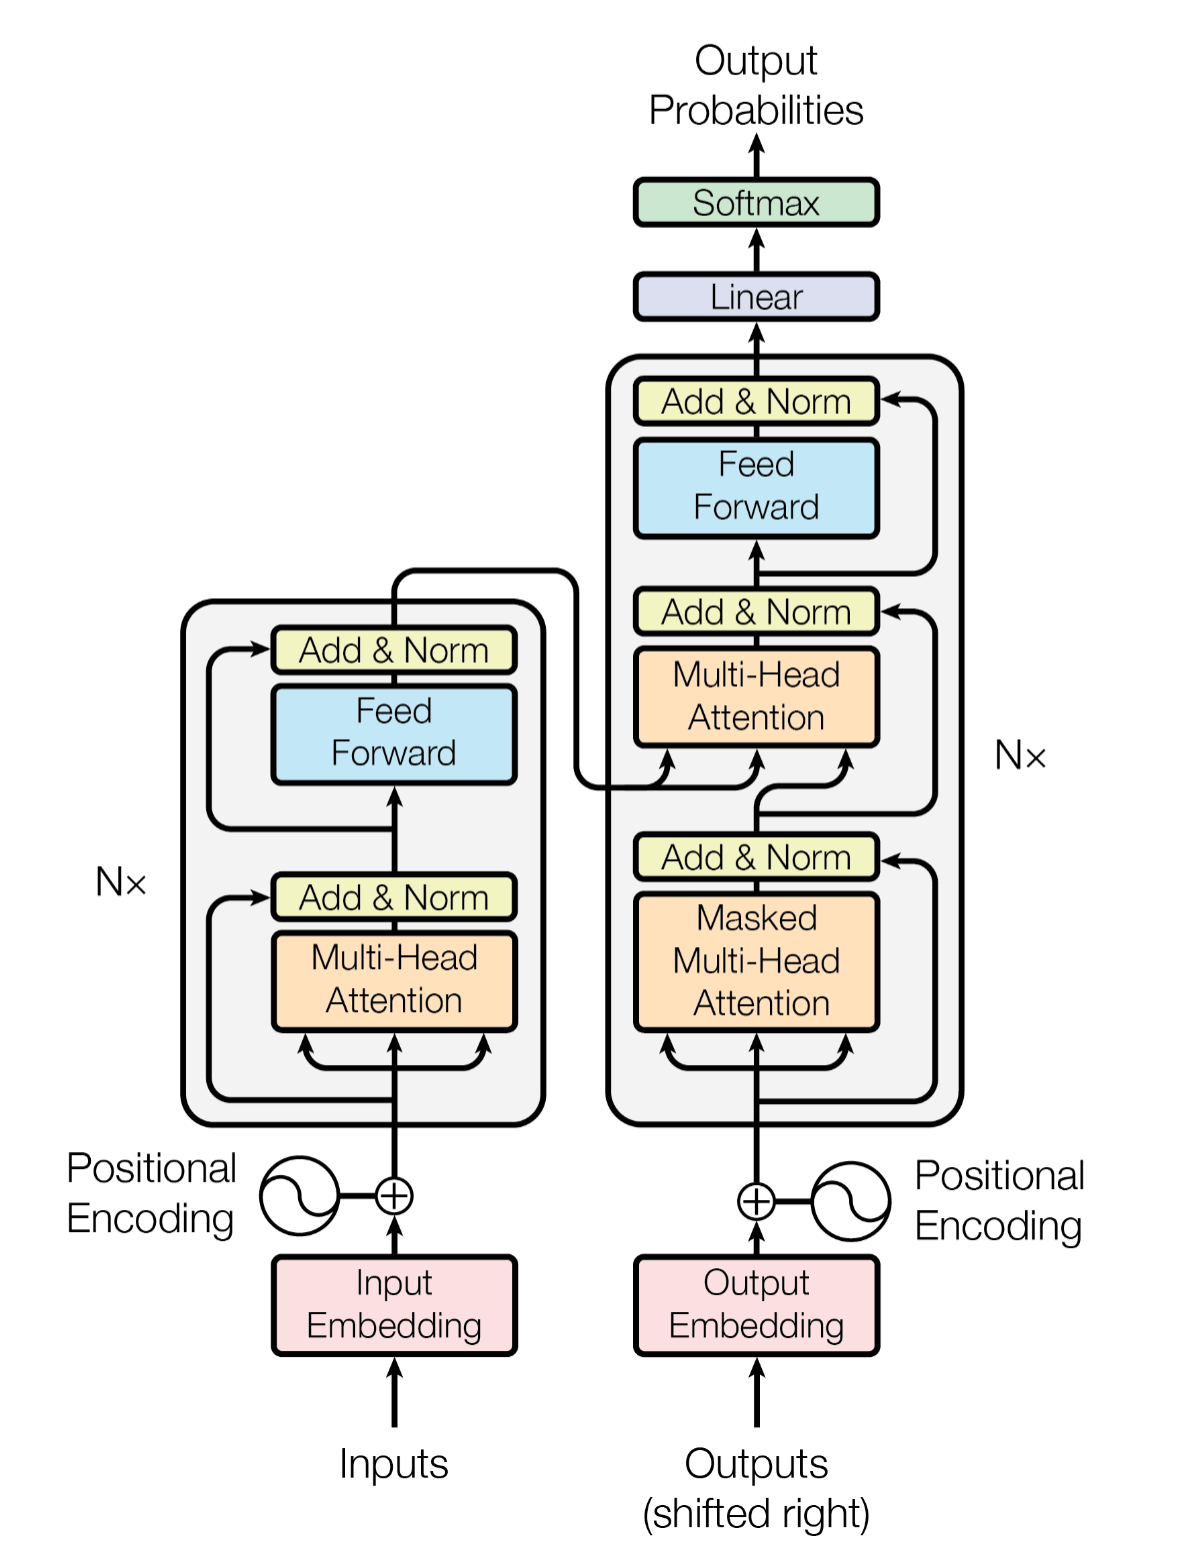

## 2. Preparando o ambiente

Não vamos usar `torchtext`. O objetivo é manter a implementação simples, explícita e independente de APIs que mudaram ao longo das versões do PyTorch.

In [ ]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos as sementes para tornar a aula reproduzível
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Reduzimos o número de threads para manter o notebook leve em ambientes didáticos
torch.set_num_threads(2)

print("PyTorch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

## 3. Um exemplo que vamos acompanhar

Vamos usar frases simples sobre equipamentos industriais.

Por exemplo:

> `the engine is hot`

A saída desejada será:

> `o motor esta quente`

O vocabulário será pequeno de propósito. Isso nos permite concentrar a atenção nos mecanismos do Transformer.

In [ ]:
# Exemplos simples gerados automaticamente
# Cada objeto possui sua tradução e seu gênero gramatical.

objects = {
    "engine":     {"target": "motor",      "gender": "m"},
    "compressor": {"target": "compressor", "gender": "m"},
    "generator":  {"target": "gerador",    "gender": "m"},
    "pump":       {"target": "bomba",      "gender": "f"},
    "valve":      {"target": "valvula",    "gender": "f"},
    "sensor":     {"target": "sensor",     "gender": "m"},
    "machine":    {"target": "maquina",    "gender": "f"},
    "turbine":    {"target": "turbina",    "gender": "f"},
    "system":     {"target": "sistema",    "gender": "m"},
    "operator":   {"target": "operador",   "gender": "m"},
}


# Estados com formas masculina e feminina.
# Para estados invariáveis, as duas formas são iguais.

states = {
    "normal": {
        "source": "is normal",
        "target_m": "esta normal",
        "target_f": "esta normal",
    },
    "hot": {
        "source": "is hot",
        "target_m": "esta quente",
        "target_f": "esta quente",
    },
    "active": {
        "source": "is active",
        "target_m": "esta ativo",
        "target_f": "esta ativa",
    },
    "idle": {
        "source": "is idle",
        "target_m": "esta parado",
        "target_f": "esta parada",
    },
    "ready": {
        "source": "is ready",
        "target_m": "esta pronto",
        "target_f": "esta pronta",
    },
    "busy": {
        "source": "is busy",
        "target_m": "esta ocupado",
        "target_f": "esta ocupada",
    },
}


# Geramos as combinações simples
generated_examples = []

for object_name, object_info in objects.items():

    target_object = object_info["target"]
    gender = object_info["gender"]

    for state_name, state_info in states.items():

        source_text = f"the {object_name} {state_info['source']}"

        if gender == "m":
            target_state = state_info["target_m"]
        else:
            target_state = state_info["target_f"]

        target_text = f"o {target_object} {target_state}" \
            if gender == "m" \
            else f"a {target_object} {target_state}"

        generated_examples.append(
            (source_text, target_text)
        )


# Exemplos mais variados, com estruturas linguísticas diferentes
manual_examples = [

    ("the pump stopped after the alarm",
     "a bomba parou apos o alarme"),

    ("the generator requires immediate inspection",
     "o gerador requer inspecao imediata"),

    ("the valve was opened by the operator",
     "a valvula foi aberta pelo operador"),

    ("the sensor is reporting unstable values",
     "o sensor esta informando valores instaveis"),

    ("the engine returned to normal operation",
     "o motor voltou a operacao normal"),

    ("the machine stopped because of overheating",
     "a maquina parou devido ao superaquecimento"),

    ("the compressor reached the expected pressure",
     "o compressor atingiu a pressao esperada"),

    ("the turbine requires preventive maintenance",
     "a turbina requer manutencao preventiva"),

    ("the system is ready for operation",
     "o sistema esta pronto para operacao"),

]


# Combinamos os dois conjuntos
examples = generated_examples + manual_examples

# Remove possíveis duplicatas
examples = list(dict.fromkeys(examples))

## 4. Tokenização e representação numérica

Antes de qualquer rede neural, precisamos transformar texto em IDs.

Por exemplo:

`the motor is hot`

pode virar:

`[12, 7, 4, 9]`

Neste notebook usamos uma tokenização propositalmente simples, baseada em espaços. Em um modelo real poderíamos usar BPE, WordPiece, SentencePiece etc.

OBS:
- stoi = string to index

- itos = index to string

In [ ]:
# Embaralhamos e fazemos uma divisão simples treino/teste
random.Random(SEED).shuffle(examples)
# Divisão treino/teste
split_idx = int(0.8 * len(examples))

train_pairs = examples[:split_idx]
test_pairs = examples[split_idx:]


all_text = (
    [source for source, _ in examples]
    + [target for _, target in examples]
)

In [ ]:
# TODO crie o vocabulário com os tokens únicos de all_text, usando split(), set() e sorted().
tokens = ...

# TODO defina os tokens especiais <pad>, <bos>, <eos> e <unk>.
special_tokens = ...

# TODO crie itos colocando os tokens especiais antes dos demais tokens.
itos = ...

# TODO crie stoi mapeando cada token para seu índice em itos.
stoi = ...

In [ ]:
print("Total de exemplos:", len(examples))
print("Exemplos de treino:", len(train_pairs))
print("Exemplos de teste :", len(test_pairs))

print("\nTamanho do vocabulário:", len(itos))

print("\nAlguns tokens:")
for idx, token in enumerate(itos):
    print(f"{idx:2d} -> {token}")

### Visualizando o que acabou de acontecer

A tabela abaixo deixa explícita a transformação:

**palavra → índice inteiro**

É exatamente esta sequência de índices que será entregue à camada de embedding.

In [ ]:
# TODO selecione um texto de examples.
sample_text = ...
sample_text

In [ ]:
# TODO divida sample_text em tokens usando split().
sample_tokens = ...
sample_tokens

In [ ]:
# TODO converta cada token em seu ID usando stoi.
# Caso o token não exista no vocabulário, use o ID de <unk>.
sample_ids = ...

sample_ids

In [ ]:
print("Texto  :", sample_text)
print("Tokens :", sample_tokens)
print("IDs    :", sample_ids)

plt.figure(figsize=(10, 2.5))
# colocar os números em cada célula
plt.imshow(np.array(sample_ids).reshape(1, -1), aspect="auto", cmap="Blues")
plt.xticks(range(len(sample_tokens)), sample_tokens)
plt.yticks([0], ["ID"])
plt.colorbar(label="Índice do vocabulário")
plt.title("Uma sequência de texto convertida em números")
plt.tight_layout()
plt.show()

## 5. Embeddings: de ID para vetor

Um ID isolado não carrega significado semântico.

A camada de embedding transforma cada ID em um vetor denso:

`token → vetor`

Se o tamanho do embedding for 32, então uma frase com 4 tokens passa a ser uma matriz:

`4 × 32`

O Transformer trabalha, a partir daqui, com esses vetores.

A nn.Embedding começa com pesos aleatórios. No comportamento padrão do PyTorch, eles são inicializados aproximadamente segundo uma distribuição normal:


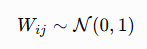

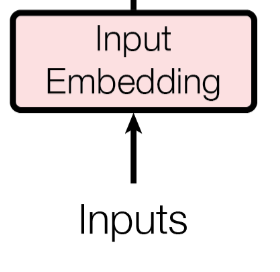

In [ ]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        """
        vocab_size: tamanho do vocabulário
        d_model: dimensão do embedding
        """
        # Traz as propriedades padrão da classe pai (nn.Module) para esta nova classe
        super().__init__()

        # TODO crie uma camada nn.Embedding com vocab_size posições
        # e d_model dimensões.
        ...

    def forward(self, token_ids):
        # TODO passe os token_ids pela camada de embedding e retorne o resultado.
        return ...

In [ ]:
# TODO defina a dimensão dos embeddings
d_model = ...

# TODO crie a camada TokenEmbedding usando o tamanho do vocabulário len(itos)
# e a dimensão d_model.
embedding_layer = ...

# TODO converta sample_ids em um tensor PyTorch de inteiros long
# e adicione uma dimensão para representar o batch.
sample_tensor = ...

# TODO passe sample_tensor pela camada de embedding para obter os embeddings.
sample_embedding = ...
sample_embedding

In [ ]:
print("Shape dos IDs       :", sample_tensor.shape)
print("Shape dos embeddings:", sample_embedding.shape)

plt.figure(figsize=(10, 4))
plt.imshow(sample_embedding[0].detach().numpy(), aspect="auto", cmap="viridis")
plt.yticks(range(len(sample_tokens)), sample_tokens)
plt.xlabel("Índice na Dimensão do embedding")
plt.ylabel("Token")
plt.colorbar(label="Valor")
plt.title("Cada token agora é representado por um vetor")
plt.tight_layout()
plt.show()

## 6. Mas onde cada token está?

Self-attention consegue relacionar tokens, mas existe um problema:

> Se trocarmos a ordem dos tokens, como o modelo saberá que a sequência mudou?

Precisamos adicionar informação de posição.

A implementação clássica do paper *Attention Is All You Need* usa funções seno e cosseno:

$$
PE_{(pos,2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

$$
PE_{(pos,2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

A ideia é simples: **o embedding informa o conteúdo; o positional encoding informa onde o token está.**

O positional encoding associa um vetor específico a cada posição da sequência. No encoding senoidal, esses vetores são determinísticos e não são aprendidos. Para uma sequência de tamanho L, usamos as L primeiras posições da matriz de positional encoding. O parâmetro max_len define quantas posições foram pré-computadas na implementação; ele não significa que posições maiores sejam representadas por zeros.

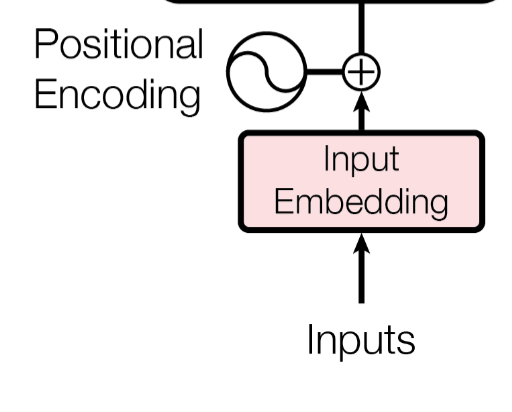

OBS:

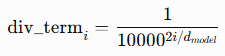

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        """
        max_len: comprimento máximo da sequência:
        o maior número de posições para o qual nós pré-computamos o positional encoding.
        d_model: dimensão do embedding
        """
        super().__init__()

        # TODO crie uma matriz de zeros com shape (max_len, d_model)
        pe = ...

        # TODO crie as posições de 0 até max_len-1 e adicione uma dimensão
        positions = ...

        # TODO calcule os termos de divisão usados nas funções seno e cosseno.
        # Ele gera diferentes escalas/frequências para as dimensões do positional encoding.
        #Por exemplo, com d_model = 4, teremos aproximadamente: div_term = [1.0000, 0.1000,0.0100,0.0010]
        #Ou seja: dimensão 0 → variação mais rápida, dimensão 1 → variação mais lenta,
        # dimensão 2 → ainda mais lenta, dimensão 3 → muito mais lenta
        div_term = ...

        # TODO aplique seno nas posições pares e cosseno nas posições ímpares.
        pe[:, 0::2] = ...
        pe[:, 1::2] = ...

        # TODO registre pe como um buffer do modelo, adicionando a dimensão do batch.
        self.register_buffer("pe", pe.unsqueeze(0))

    # TODO defina o método forward() recebendo x.
    def forward(self, x):
        # TODO some o embedding x à codificação posicional correspondente
        # ao comprimento da sequência x.
        return ...

In [ ]:
# TODO crie uma camada PositionalEncoding com max_len=20 e d_model=d_model.
positional_encoding = ...

In [ ]:
positional_encoding.pe.shape

In [ ]:
# o valor do embedding do token na posição pos_test é somado ao valor do
# embedding posicional da posição pos_test
pos_test = ...
positional_encoding.pe[0,pos_test:pos_test+1]

In [ ]:
position_vectors = positional_encoding.pe[0].numpy()

plt.figure(figsize=(12, 5))
plt.imshow(position_vectors, aspect="auto", cmap="coolwarm")
plt.xlabel("Dimensão do embedding")
plt.ylabel("Posição")
plt.colorbar(label="Valor")
plt.title("Positional encoding: padrões diferentes para cada posição")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(position_vectors[:, 0], label="Dimensão 0")
plt.plot(position_vectors[:, 1], label="Dimensão 1")
plt.xlabel("Posição")
plt.ylabel("Valor")
plt.title("Duas dimensões do positional encoding")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Self-attention: a ideia fundamental

Tendo como exemplo a frase:
"A temperatura do reator aumentou porque o sistema de resfriamento falhou."

Para cada token, criamos três representações:

---
- **Query (Q):** o que este token precisa saber?

Por exemplo, para o token "aumentou", a Query pode estar procurando:
  - Quem aumentou?
  - O que causou o aumento?
  - Alguma variável física relacionada?

----

- **Key (K):** que tipo de informação pode ser oferecida?
| Token                    | Key representa    |
|--------------------------|-------------------|
| A                        | artigo            |
| temperatura              | variável física   |
| do                       | conexão gramatical|
| reator                   | equipamento       |
| aumentou                 | mudança de estado |
| porque                   | relação causal    |
| o                        | artigo            |
| sistema de resfriamento  | sistema auxiliar  |
| falhou                   | falha             |

-----
- **Value (V):** Comparação Query × Key: qual informação será transferida se um determinado token for considerado relevante?

Matematicamente:
$$
\text{score}_{ij} = Q_i K_j^T
$$
onde:
- $i$ = token que está consultando
- $j$ = token sendo avaliado

-----

A operação central é:

$$
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Vamos separar esta fórmula em etapas, porque é justamente isso que o código real faz.

softmax:

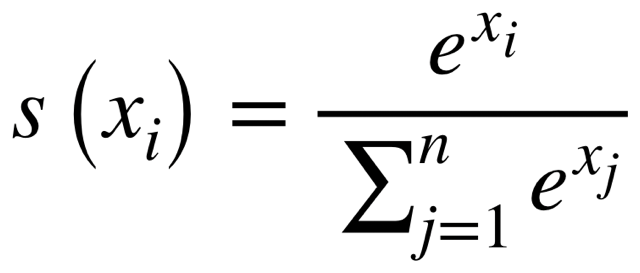

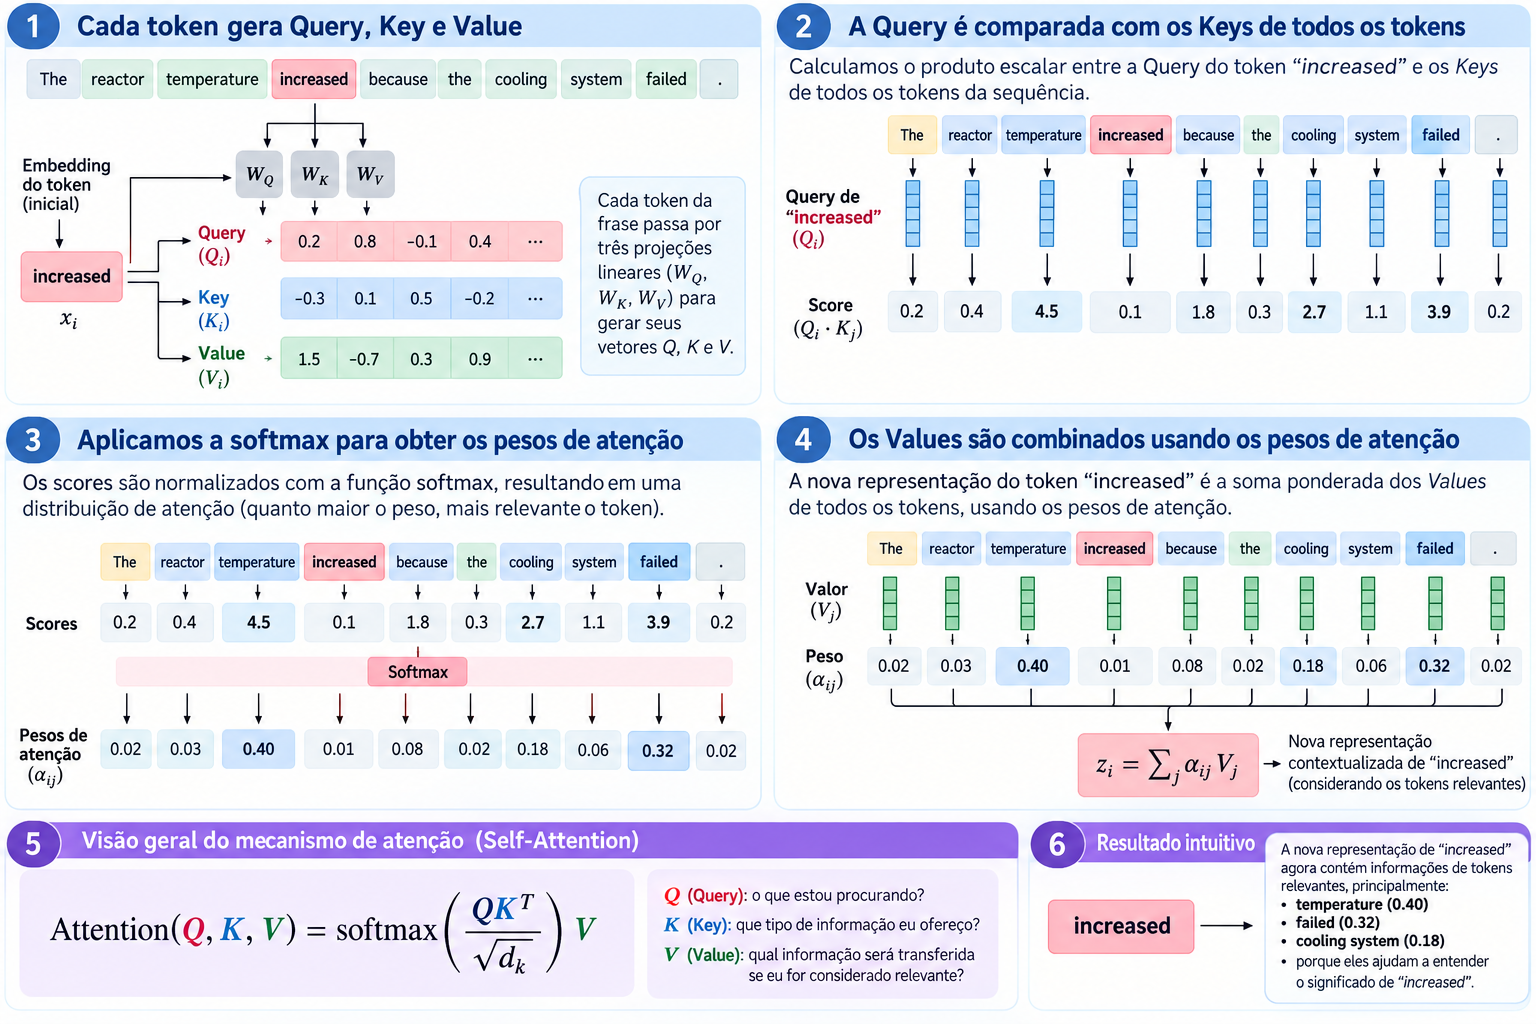

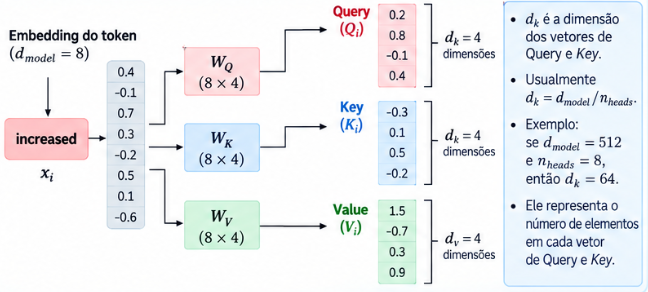

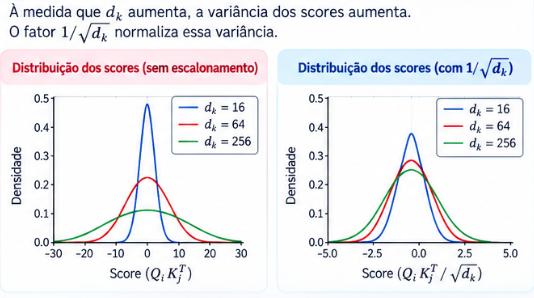

### 7.1 Passo 1 — gerar Q, K e V

Partimos da matriz de representação `X`.

Aplicamos três transformações lineares:

$$
Q=XW_Q, \quad K=XW_K, \quad V=XW_V
$$

As matrizes $W_Q$, $W_K$ e $W_V$ são parâmetros aprendidos durante o treinamento.

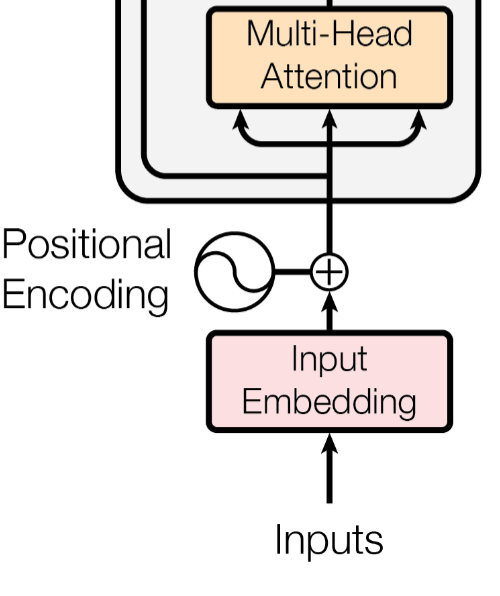

In [ ]:
torch.manual_seed(SEED)
embedding_layer = TokenEmbedding(len(itos), d_model)

sample_text = examples[15][0]
sample_tokens = sample_text.split()
sample_ids = [stoi.get(token, stoi["<unk>"]) for token in sample_tokens]

sample_tensor = torch.tensor([sample_ids], dtype=torch.long)
sample_embedding = embedding_layer(sample_tensor)
sample_embedding

In [ ]:
# TODO aplique positional_encoding sobre sample_embedding e use [0]
# para remover a dimensão do batch.
X = ...
print("X shape:", X.shape)

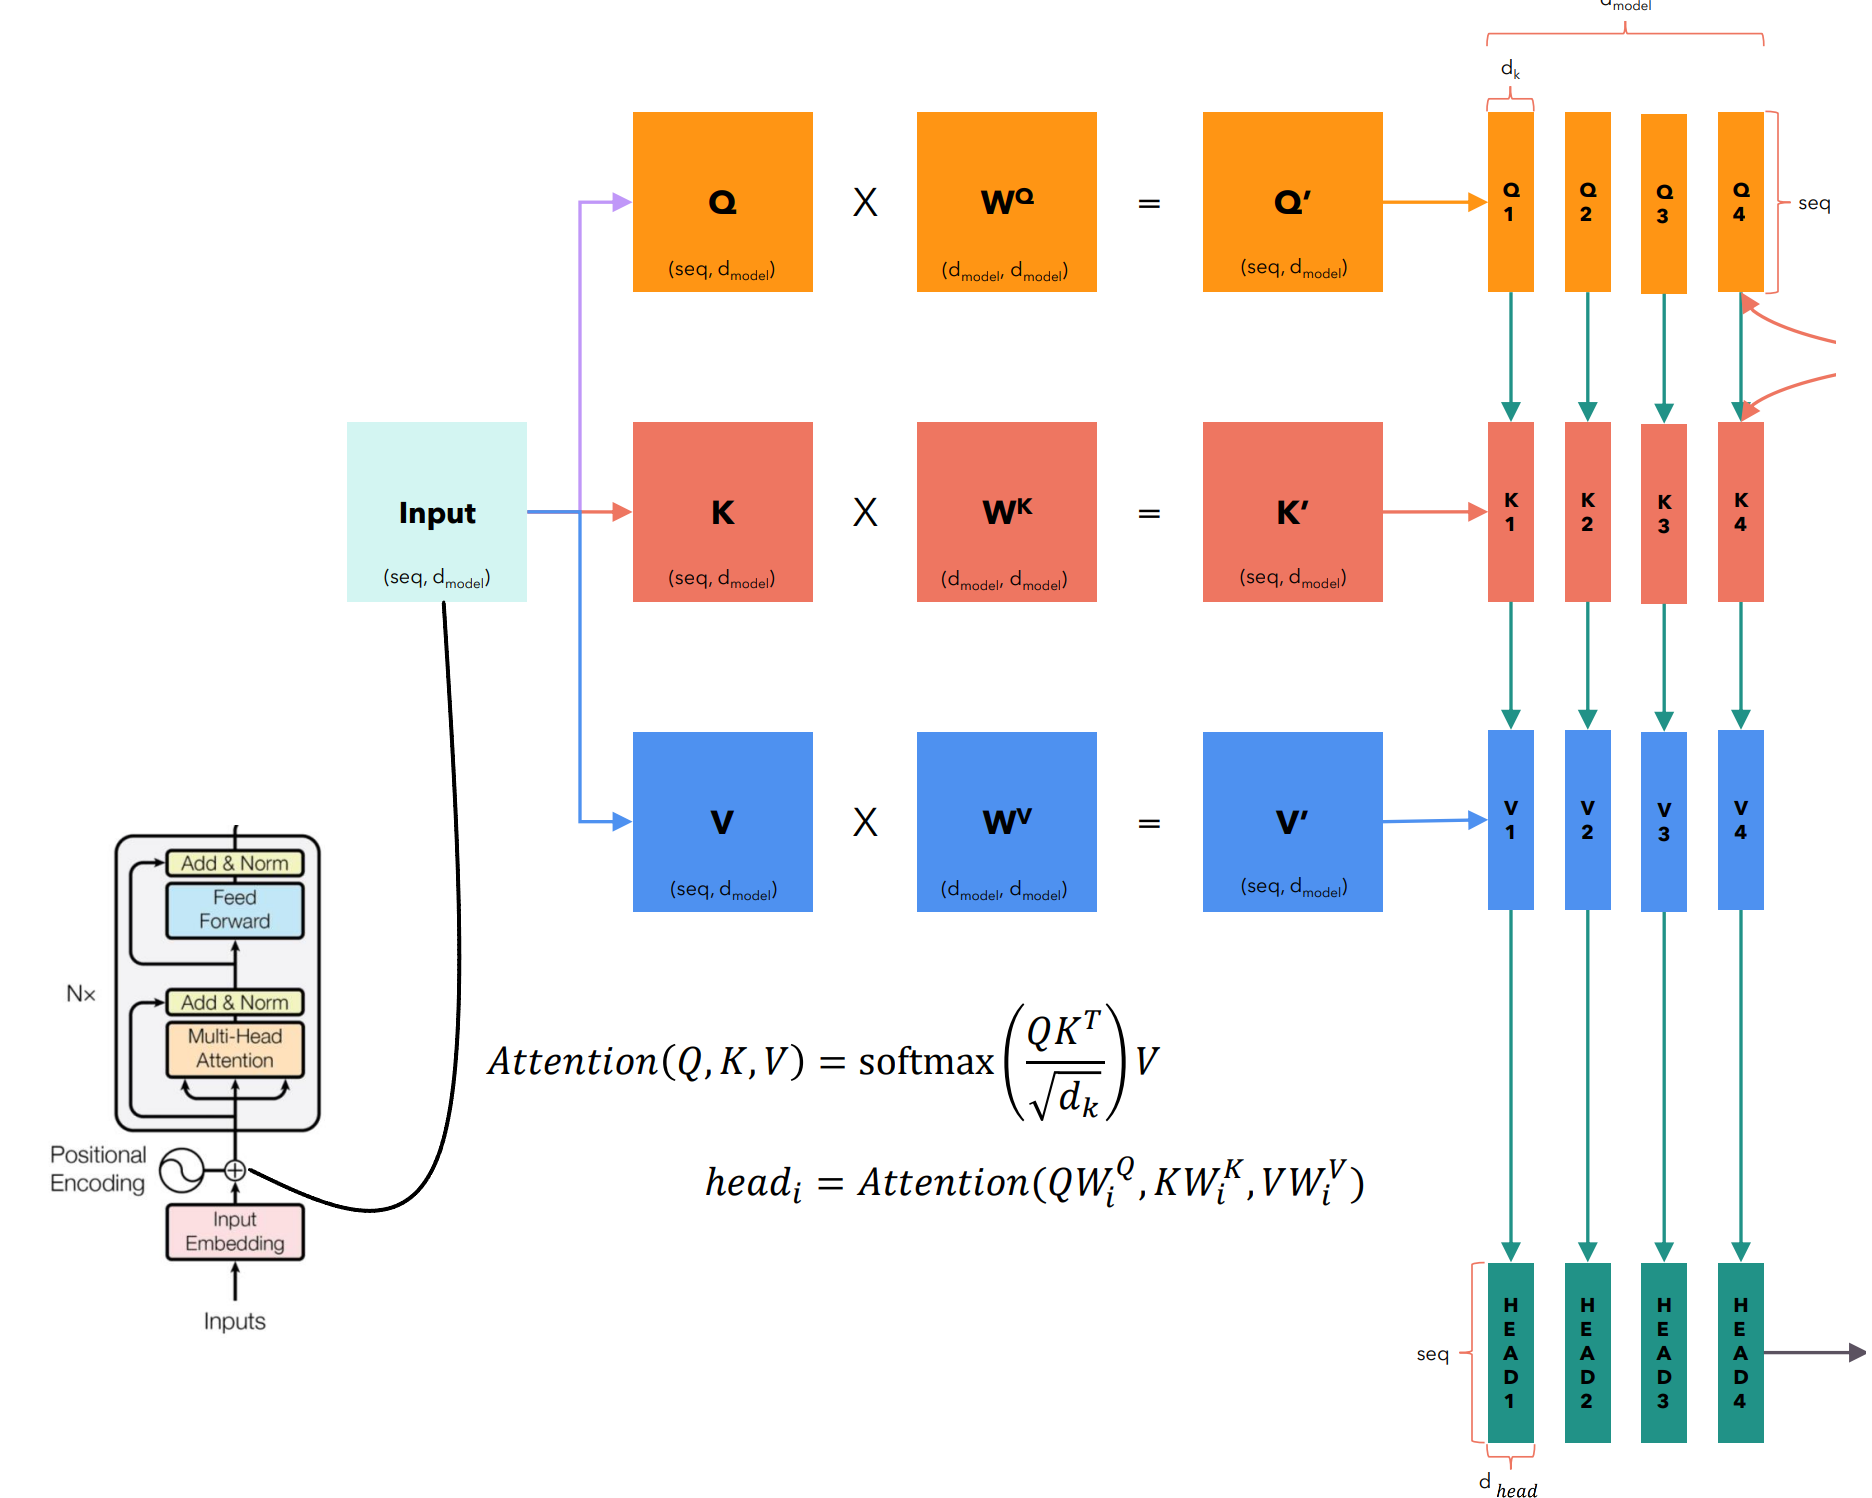

Exemplo para uma HEAD:

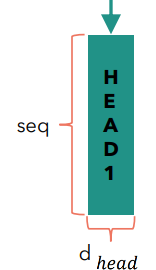

In [ ]:
# TODO defina d_head=4 como a dimensão das representações de cada cabeça de atenção.
d_head = ...

# TODO crie a matriz W_Q com shape (d_model, d_head) usando valores aleatórios.
W_Q = ...

# TODO crie a matriz W_K com shape (d_model, d_head) usando valores aleatórios.
W_K = ...

# TODO crie a matriz W_V com shape (d_model, d_head) usando valores aleatórios.
W_V = ...

# TODO projete X para obter as queries usando Q = X @ W_Q.
Q = ...

# TODO projete X para obter as keys usando K = X @ W_K.
K = ...

# TODO projete X para obter os values usando V = X @ W_V.
V = ...

In [ ]:
print("X:", X.shape)
print("Q:", Q.shape)
print("K:", K.shape)
print("V:", V.shape)
print("\nExemplo: Q da palavra 'hot'")
print(Q[-1])

### 7.2 Passo 2 — comparar Queries e Keys

Agora calculamos:

$$
Scores = QK^T
$$

Cada posição da matriz diz:

> **“O quanto a Query de um token se parece com a Key de outro token?”**

A diagonal não é especial por definição. O importante é que **cada linha representa um token consultando toda a sequência**.

In [ ]:
scores = Q @ K.T # @: dot product

print("Shape da matriz de scores:", scores.shape)

plt.figure(figsize=(7, 6))
sns.heatmap(
    scores.detach().numpy(),
    xticklabels=sample_tokens,
    yticklabels=sample_tokens,
    annot=True,
    fmt=".1f",
    cmap="magma"
)
plt.xlabel("Keys")
plt.ylabel("Queries")
plt.title("Scores: cada token compara sua Query com todas as Keys")
plt.tight_layout()
plt.show()

Cada valor representa a compatibilidade entre uma Query (linha) e uma Key (coluna):
- linha → quem está perguntando (Query)
- coluna → quem está sendo consultado (Key)
- valor → resultado da compatibilidade entre os dois

### 7.3 Passo 3 — escalar e aplicar softmax

A multiplicação pode produzir valores grandes. Por isso dividimos por:

$$
\sqrt{d_k}
$$ (fator de escala baseado na dimensão dos vetores de Key e Query)



Depois aplicamos softmax linha a linha.

O resultado deixa de ser um conjunto arbitrário de números e passa a ser uma **distribuição de atenção**:

- cada linha soma aproximadamente 1;
- quanto maior o valor, maior o peso dado àquela posição.

In [ ]:
# TODO escale os scores dividindo pela raiz quadrada da dimensão de Q (Q e K têm a mesma dimensão).
scaled_scores = ...

# TODO aplique softmax na última dimensão para transformar os scores
# em pesos de atenção.
attention_weights = ...

In [ ]:
print("Soma de cada linha:")
print(attention_weights.sum(dim=-1))

plt.figure(figsize=(7, 6))
sns.heatmap(
    attention_weights.detach().numpy(),
    xticklabels=sample_tokens,
    yticklabels=sample_tokens,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1
)
plt.xlabel("Keys")
plt.ylabel("Queries")
plt.title("Distribuição de self-attention após softmax")
plt.tight_layout()
plt.show()

### 7.4 Passo 4 — combinar os Values

Finalmente:

$$
Context = AttentionWeights \cdot V
$$

Ou seja:

> uma posição produz uma nova representação que é uma combinação ponderada das informações presentes em outras posições.

In [ ]:
context = attention_weights @ V

print("Shape do contexto:", context.shape)

plt.figure(figsize=(9, 4))
sns.heatmap(
    context.detach().numpy(),
    xticklabels=range(d_head),
    yticklabels=sample_tokens,
    annot=True,
    fmt=".1f",
    cmap="magma"
)
plt.yticks(range(len(sample_tokens)), sample_tokens)
plt.xlabel("Dimensão do vetor contextualizado")
plt.ylabel("Token")
plt.title("Representação contextualizada produzida pela atenção")
plt.tight_layout()
plt.show()



Os Novo vetores depois da atenção agora passam a ter uma representação que incorpora informação de outros tokens.

## 8. Uma implementação explícita de Scaled Dot-Product Attention

Agora vamos encapsular exatamente as etapas que acabamos de calcular:

1. `Q @ Kᵀ`
2. divisão por `sqrt(d_k)`
3. máscara opcional
4. `softmax`
5. multiplicação pelos `V`

Ter o código explícito é importante neste ponto da aula: ele mostra que “attention” não é uma caixa-preta.

In [ ]:
def scaled_dot_product_attention(query, key, value, mask=None):
    # TODO calcule a similaridade entre Query e Key usando produto matricial.
    scores = ...

    # TODO escale os scores dividindo pela raiz quadrada da dimensão de Query.
    scores = ...

    # TODO se uma máscara for fornecida, substitua as posições bloqueadas por um valor muito negativo.
    if mask is not None:
        scores = ...

    # TODO aplique softmax na última dimensão para obter os pesos de atenção.
    weights = ...

    # TODO calcule o contexto como a soma ponderada dos Values.
    context = ...

    return context, weights

In [ ]:
# TODO aplique scaled_dot_product_attention() usando Q, K e V
# e armazene o contexto e os pesos de atenção retornados.
toy_context, toy_weights = ...
print(toy_context)
print(toy_weights)

In [ ]:
print("Contexto:", toy_context.shape)
print("Pesos   :", toy_weights.shape)

plt.figure(figsize=(7, 6))
sns.heatmap(
    toy_weights.detach().numpy(),
    xticklabels=sample_tokens,
    yticklabels=sample_tokens,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1
)
plt.xlabel("Keys")
plt.ylabel("Queries")
plt.title("Nossa função reproduzindo a matriz de atenção")
plt.tight_layout()
plt.show()

## 9. Multi-Head Attention

Uma única matriz de atenção pode aprender um tipo de relação.

Com **múltiplas cabeças**, diferentes grupos de dimensões podem aprender relações diferentes.

Se:

- $d_{model}=32$
- `4 heads`

então cada cabeça trabalha com:

$$
d_{head}=32/4=8
$$

O fluxo fica:

**32 dimensões → 4 cabeças de 8 dimensões → atenção em paralelo → concatenação → projeção final**

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()

        assert d_model % n_heads == 0

        # TODO armazene d_model, n_heads e calcule d_head = d_model // n_heads.
        self.d_model = ...
        self.n_heads = ...
        self.d_head = ...

        # TODO crie as projeções lineares de Query, Key, Value e saída.
        # Todas devem receber e produzir vetores de dimensão d_model,
        # usando bias=False.
        self.q_proj = ...
        self.k_proj = ...
        self.v_proj = ...
        self.out_proj = ...

        # TODO crie uma camada Dropout usando a taxa recebida.
        self.dropout = ...

    def forward(self, x, mask=None, return_attention=False):
        batch_size, seq_len, _ = x.shape

        # Projetamos e dividimos o vetor em múltiplas cabeças
        # TODO projete x em Q, K e V e reorganize cada vetor em n_heads
        # com d_head dimensões.
        q = ...
        k = ...
        v = ...

        # Levamos a dimensão das cabeças para frente para alinhar com o que scaled dot-product attention espera
        # antes: [batch, posição, cabeça, dimensão]
        # depois: [batch, cabeça, posição, dimensão]
        # TODO mova a dimensão das cabeças para a segunda posição.
        q = ...
        k = ...
        v = ...

        # TODO calcule a atenção usando scaled_dot_product_attention().
        context, attention = ...

        # Reunimos novamente as cabeças usando contiguous() para garantir que
        # o tensor esteja organizado de forma contígua na memória
        # TODO reúna novamente as múltiplas cabeças.
        context = ...
        context = ...

        # TODO aplique a projeção final.
        output = ...

        if return_attention:
            return output, attention

        return output

In [ ]:
# TODO crie uma camada MultiHeadAttention com d_model=32 e n_heads=4.
multi_head = ...

# TODO aplique positional_encoding sobre sample_embedding
# para gerar a entrada da atenção multi-head.
demo_input = ...

# TODO passe demo_input pela camada multi_head com return_attention=True
# para obter tanto a saída quanto os pesos de atenção.
mh_output, mh_attention = ...

In [ ]:
print("Entrada :", demo_input.shape)
print("Saída   :", mh_output.shape)
print("Atenção :", mh_attention.shape)

### Visualizando as diferentes cabeças

Cada cabeça possui sua própria matriz de atenção.

Não devemos interpretar automaticamente cada cabeça como uma “regra semântica fixa”. O ponto didático é observar que **o modelo possui vários espaços de atenção em paralelo**.

In [ ]:
n_heads_ = mh_attention.shape[1]
d_head_ = mh_output.shape[-1] // n_heads_

for head in range(n_heads_):

    # Attention da cabeça atual
    attention = mh_attention[0, head].detach().numpy()

    # Output correspondente à cabeça atual
    output = mh_output[0, :, head * d_head:(head + 1) * d_head].detach().numpy()

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 5)
    )

    # --- Attention ---
    sns.heatmap(
        attention,
        xticklabels=sample_tokens,
        yticklabels=sample_tokens,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        ax=axes[0]
    )

    axes[0].set_xlabel("Keys")
    axes[0].set_ylabel("Queries")
    axes[0].set_title(f"Cabeça {head + 1} — mapa de atenção")

    # --- Output ---
    sns.heatmap(
        output,
        xticklabels=[f"Dim {i+1}" for i in range(d_head)],
        yticklabels=sample_tokens,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        ax=axes[1]
    )

    axes[1].set_xlabel("Dimensão")
    axes[1].set_ylabel("Token")
    axes[1].set_title(f"Cabeça {head + 1} — representação contextualizada")

    plt.tight_layout()
    plt.show()

## 10. Termianndo o bloco Encoder
#### Principais mecanismos do encoder feito!


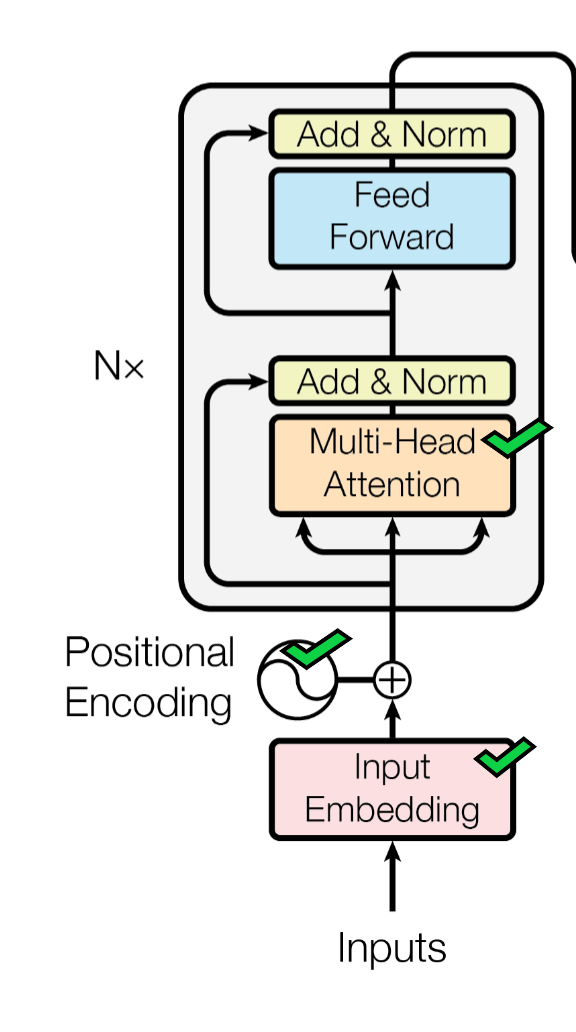

Até aqui temos o mecanismo de atenção.

Mas um Transformer completo combina:

**atenção + conexão residual + normalização + feed-forward**

No encoder, o fluxo didático é:

`X → Multi-Head Self-Attention → Add & Norm → Feed Forward → Add & Norm`

O **Feed Forward Network (FFN)** é aplicado independentemente a cada posição da sequência.

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        # TODO crie uma rede Sequential com:
        # Linear(d_model, d_ff) → ReLU → Dropout(dropout) → Linear(d_ff, d_model).
        self.network = ...

    def forward(self, x):
        # TODO passe x pela rede FeedForward e retorne o resultado.
        return ...

In [ ]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        # TODO crie a camada de MultiHeadAttention com d_model, n_heads e dropout.
        self.attention = ...
        # TODO crie LayerNorm para normalizar a saída da primeira subcamada.
        self.norm1 = ...
        # TODO crie a rede FeedForward com d_model, d_ff e dropout.
        self.feed_forward = ...
        # TODO crie LayerNorm para normalizar a saída da segunda subcamada.
        self.norm2 = ...
        # TODO crie Dropout usando a taxa dropout.
        self.dropout = ...

    def forward(self, x, mask=None, return_attention=False):
        # Primeira subcamada: self-attention
        # TODO aplique self-attention sobre x e obtenha também os pesos de atenção.
        attention_output, attention_weights = ...

        # Conexão residual seguida de normalização
        # zera aleatoriamente alguns elementos do vetor attention_output
        # TODO aplique dropout à saída da atenção, some a conexão residual
        # com x e depois aplique LayerNorm usando norm1.
        x = ...

        # Segunda subcamada: feed-forward
        # TODO passe x pela rede FeedForward.
        feed_forward_output = ...

        # Segunda conexão residual seguida de normalização
        # TODO aplique a segunda conexão residual e LayerNorm usando norm2.
        x = ...

        if return_attention:
            return x, attention_weights

        return x

In [ ]:
demo_input

In [ ]:
# TODO crie um EncoderBlock com d_model=32, n_heads=4 e d_ff=64.
encoder_block = ...

# TODO passe demo_input pelo EncoderBlock com return_attention=True
# para obter a saída do encoder e os pesos de atenção.
encoder_output, encoder_attention = ...

In [ ]:
print("Entrada do bloco :", demo_input.shape)
print("Saída do bloco   :", encoder_output.shape)

### O efeito da normalização

O `LayerNorm` ajuda a manter as representações em uma escala controlada.

Vamos olhar para a distribuição dos valores antes e depois do bloco.

In [ ]:
before = demo_input.detach().numpy().ravel()
after = encoder_output.detach().numpy().ravel()

plt.figure(figsize=(9, 4))
plt.hist(before, bins=30, alpha=0.6, label="Antes do bloco")
plt.hist(after, bins=30, alpha=0.6, label="Depois do bloco")
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.title("Distribuição das representações")
plt.legend()
plt.tight_layout()
plt.show()

print("Média antes :", before.mean())
print("Média depois:", after.mean())
print("Desvio antes:", before.std())
print("Desvio depois:", after.std())

#### Encoder pronto!

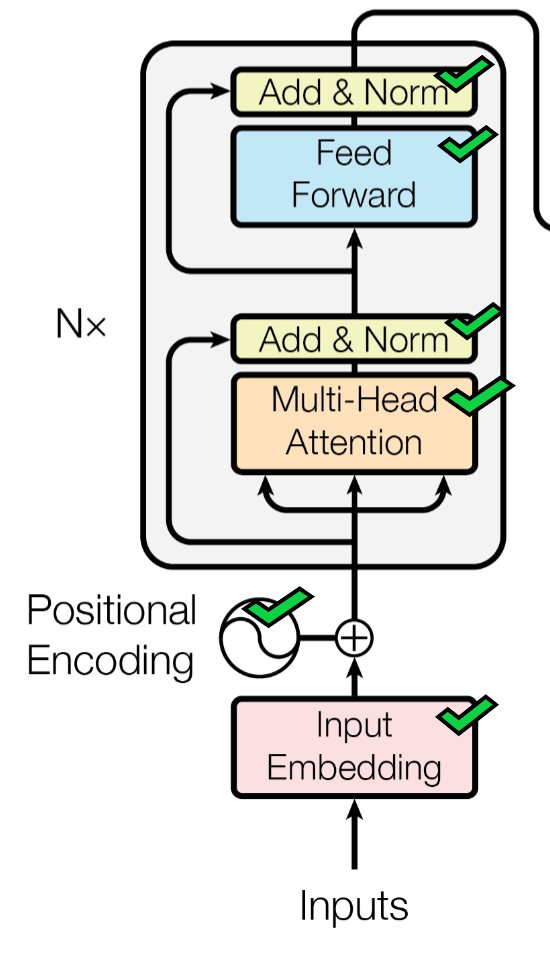

## 11. Bloco Decoder

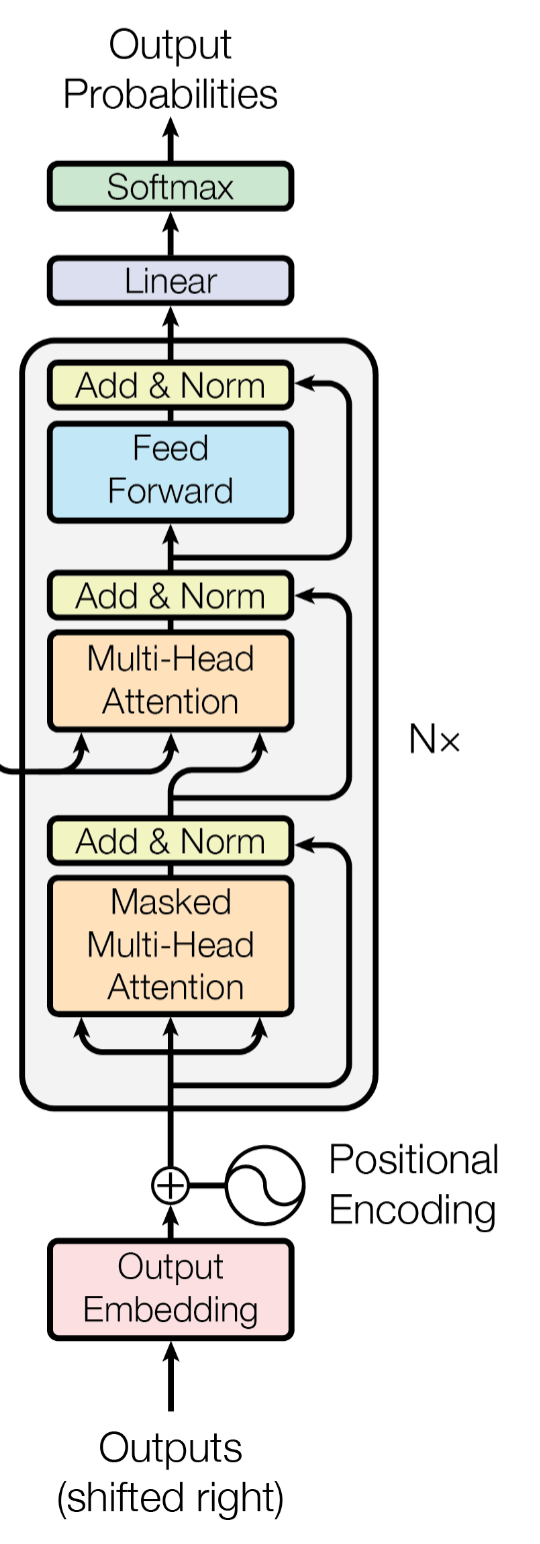

## 10. Máscara causal

No decoder, durante a geração autoregressiva, o token atual **não pode olhar para o futuro**.

Se estamos gerando:

`o motor ...`

não podemos permitir que a posição de `motor` consulte uma palavra futura que ainda não foi gerada.

Por isso usamos uma máscara triangular:

```text
1 0 0 0
1 1 0 0
1 1 1 0
1 1 1 1
```

`1` = pode olhar

`0` = não pode olhar

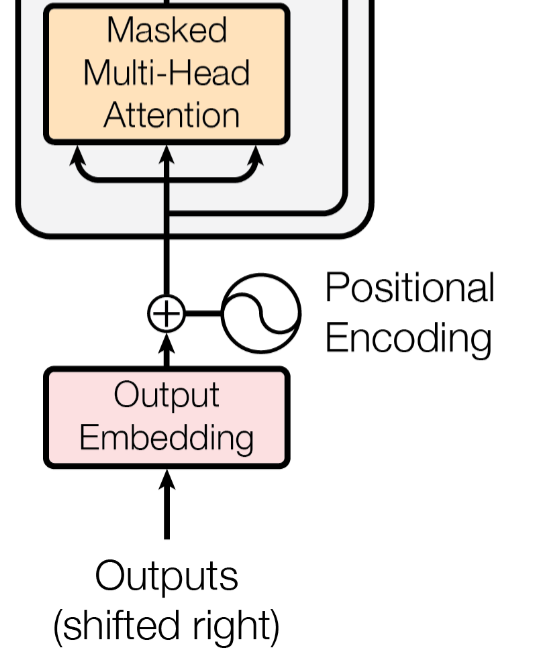

In [ ]:
def causal_mask(size, device=None):
    # Construímos a matriz triangular inferior
    mask = torch.tril(torch.ones(size, size, dtype=torch.bool, device=device))

    # Adicionamos dimensões para broadcasting entre batch e heads
    return mask.unsqueeze(0).unsqueeze(0)

In [ ]:
# X has shape: [sequence_length, d_model]
print("Shape de X:", X.shape)
print("Tokens:", sample_tokens)

seq_len = X.size(0)

# Máscara causal com o mesmo número de tokens da sequência
mask = causal_mask(seq_len, device=X.device)

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    mask[0, 0].cpu().numpy().astype(int),
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=sample_tokens,
    yticklabels=sample_tokens
)
plt.xlabel("Posição consultada (Key)")
plt.ylabel("Posição atual (Query)")
plt.title("Máscara causal")
plt.tight_layout()
plt.show()

### O efeito da máscara sobre a atenção

Vamos pegar uma distribuição de atenção e impedir explicitamente o acesso ao futuro.

O softmax transforma os valores proibidos em pesos praticamente zero.

In [ ]:
# Projetamos X em Q, K e V
torch.manual_seed(SEED)

head_dim = 8

W_q = nn.Linear(d_model, head_dim, bias=False)
W_k = nn.Linear(d_model, head_dim, bias=False)
W_v = nn.Linear(d_model, head_dim, bias=False)

q = W_q(X).unsqueeze(0).unsqueeze(0)
k = W_k(X).unsqueeze(0).unsqueeze(0)
v = W_v(X).unsqueeze(0).unsqueeze(0)

print("Q shape:", q.shape)
print("K shape:", k.shape)
print("V shape:", v.shape)


# Self-attention sem máscara
_, unrestricted_attention = scaled_dot_product_attention(q, k, v)

# Self-attention com máscara causal
_, masked_attention = scaled_dot_product_attention(
    q, k, v, mask=mask
)


# Atenção sem máscara
plt.figure(figsize=(7, 5))
sns.heatmap(
    unrestricted_attention[0, 0].detach().cpu().numpy(),
    cmap="Blues",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    xticklabels=sample_tokens,
    yticklabels=sample_tokens
)
plt.xlabel("Key")
plt.ylabel("Query")
plt.title("Self-attention sem máscara")
plt.tight_layout()
plt.show()


# Atenção com máscara causal
plt.figure(figsize=(7, 5))
sns.heatmap(
    masked_attention[0, 0].detach().cpu().numpy(),
    cmap="Blues",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    xticklabels=sample_tokens,
    yticklabels=sample_tokens
)
plt.xlabel("Key")
plt.ylabel("Query")
plt.title("Self-attention com máscara causal")
plt.tight_layout()
plt.show()

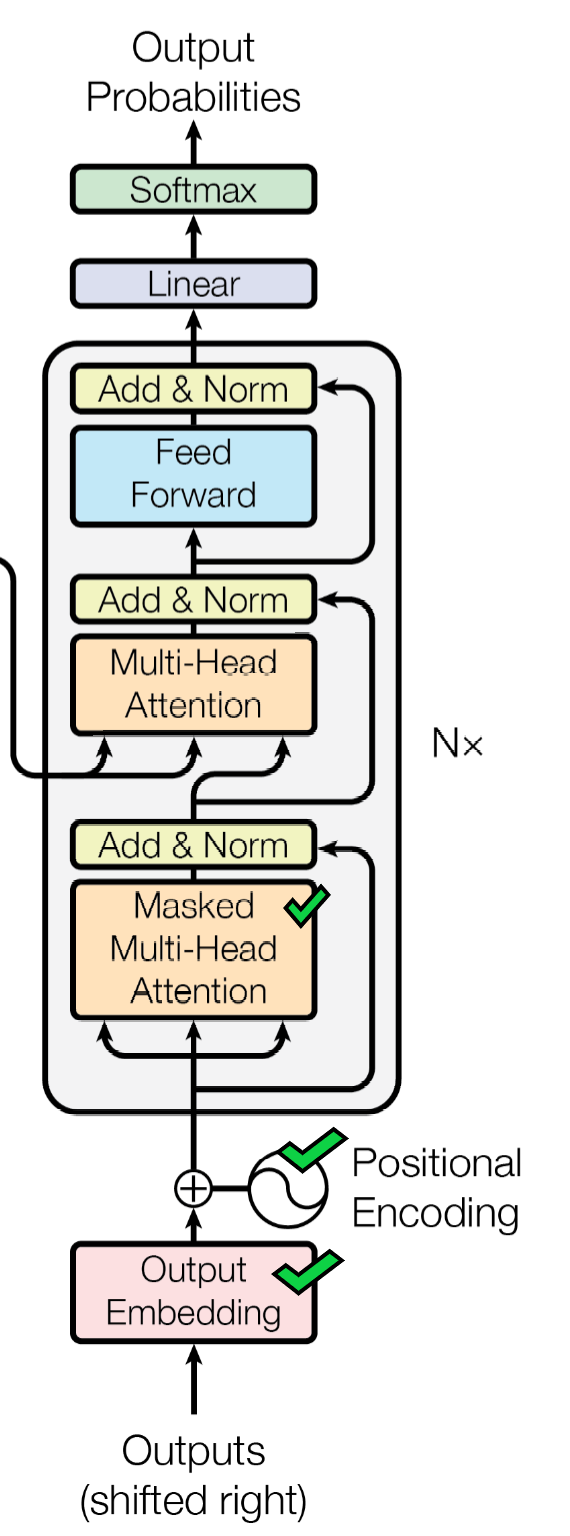

## 12. Decoder: self-attention + cross-attention

O decoder introduz duas ideias novas.

### 1. Masked self-attention

O decoder olha para aquilo que já foi gerado, mas não para o futuro.

### 2. Cross-attention

Agora o decoder consulta a saída do encoder.

Aqui a Query vem do decoder e as Keys/Values vêm do encoder:

$$
Attention(Q_{decoder},K_{encoder},V_{encoder})
$$

Essa é a ponte que permite que a geração considere a sequência de entrada.

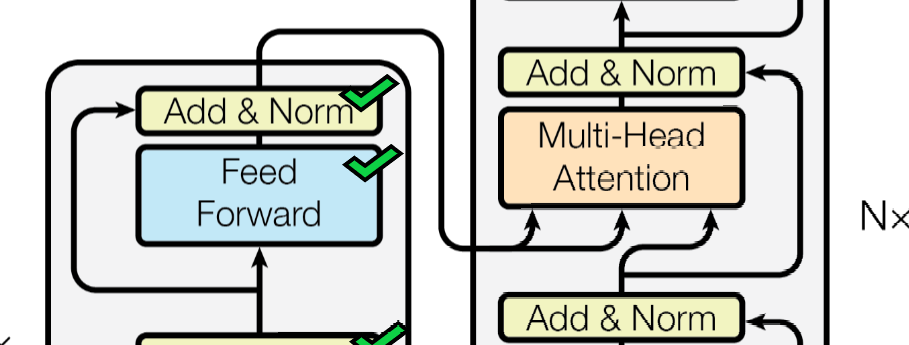

In [ ]:
class CrossAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()

        assert d_model % n_heads == 0

        # TODO armazene d_model, n_heads e d_head=d_model//n_heads.
        self.d_model = ...
        self.n_heads = ...
        self.d_head = ...

        # TODO crie as projeções lineares de Q, K, V e saída com bias=False.
        self.q_proj = ...
        self.k_proj = ...
        self.v_proj = ...
        self.out_proj = ...

        # TODO crie uma camada Dropout usando dropout.
        self.dropout = ...

    def forward(self, query, key_value, mask=None, return_attention=False):
        # TODO obtenha batch_size e os comprimentos de query e key_value.
        batch_size = ...
        query_len = ...
        key_len = ...

        # A Query vem do decoder
        # TODO projete query em Q usando q_proj, reorganize para múltiplas cabeças
        # e mova a dimensão das heads para a segunda posição.
        q = ...

        # Keys e Values vêm do encoder
        # TODO projete key_value em K usando k_proj e reorganize para múltiplas cabeças.
        k = ...

        # TODO projete key_value em V usando v_proj e reorganize para múltiplas cabeças.
        v = ...

        # TODO calcule a atenção usando scaled_dot_product_attention().
        context, attention = ...

        # TODO reúna novamente as cabeças e recupere a dimensão d_model.
        context = ...
        context = ...

        # TODO aplique a projeção final.
        output = ...

        if return_attention:
            return output, attention

        return output

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        # TODO crie a self-attention, a normalização correspondente,
        # a cross-attention, três normalizações e a camada Dropout.
        self.self_attention = ...
        self.norm1 = ...
        self.cross_attention = ...
        self.norm2 = ...
        self.feed_forward = ...
        self.norm3 = ...
        self.dropout = ...

    def forward(self, x, memory, tgt_mask=None, return_attention=False):
        # Primeiro: masked self-attention
        # TODO aplique a masked self-attention sobre x usando tgt_mask.
        # Retorne também os respectivos pesos de atenção.
        self_output, self_weights = ...

        # TODO aplique conexão residual, Dropout e LayerNorm.
        x = ...

        # Segundo: cross-attention entre decoder e encoder
        # TODO aplique cross-attention usando x como Query e memory como Key e Value.
        # Retorne também os respectivos pesos de atenção.
        cross_output, cross_weights = ...

        # TODO aplique a segunda conexão residual, Dropout e LayerNorm.
        x = ...

        # Terceiro: feed-forward
        # TODO passe x pela rede FeedForward e aplique a terceira conexão residual
        # seguida de LayerNorm.
        x = ...

        if return_attention:
            return x, self_weights, cross_weights

        return x

In [ ]:
decoder_demo = DecoderBlock(
    d_model=32,
    n_heads=4,
    d_ff=64
)

decoder_input = torch.randn(1, 4, 32)
#saída do encoder que será usada pelo decoder durante a cross-attention.
encoder_memory = torch.randn(1, 5, 32)

decoder_output, decoder_self_attention, decoder_cross_attention = decoder_demo(
    decoder_input,
    encoder_memory,
    tgt_mask=causal_mask(4),
    return_attention=True
)

print("Decoder input   :", decoder_input.shape)
print("Encoder memory  :", encoder_memory.shape)
print("Decoder output  :", decoder_output.shape)
print("Self-attention  :", decoder_self_attention.shape)
print("Cross-attention :", decoder_cross_attention.shape)

### Visualizando a cross-attention

Nesta figura, as linhas pertencem ao decoder e as colunas pertencem ao encoder.

A interpretação visual é:

> **“Para produzir cada representação no decoder, para quais posições da entrada eu estou olhando?”**

In [ ]:
plt.figure(figsize=(7, 4))
sns.heatmap(
    decoder_cross_attention[0, 0].detach().numpy(),
    cmap="Blues",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1
)
plt.xlabel("Posições do encoder")
plt.ylabel("Posições do decoder")
plt.title("Exemplo de cross-attention — uma cabeça")
plt.tight_layout()
plt.show()

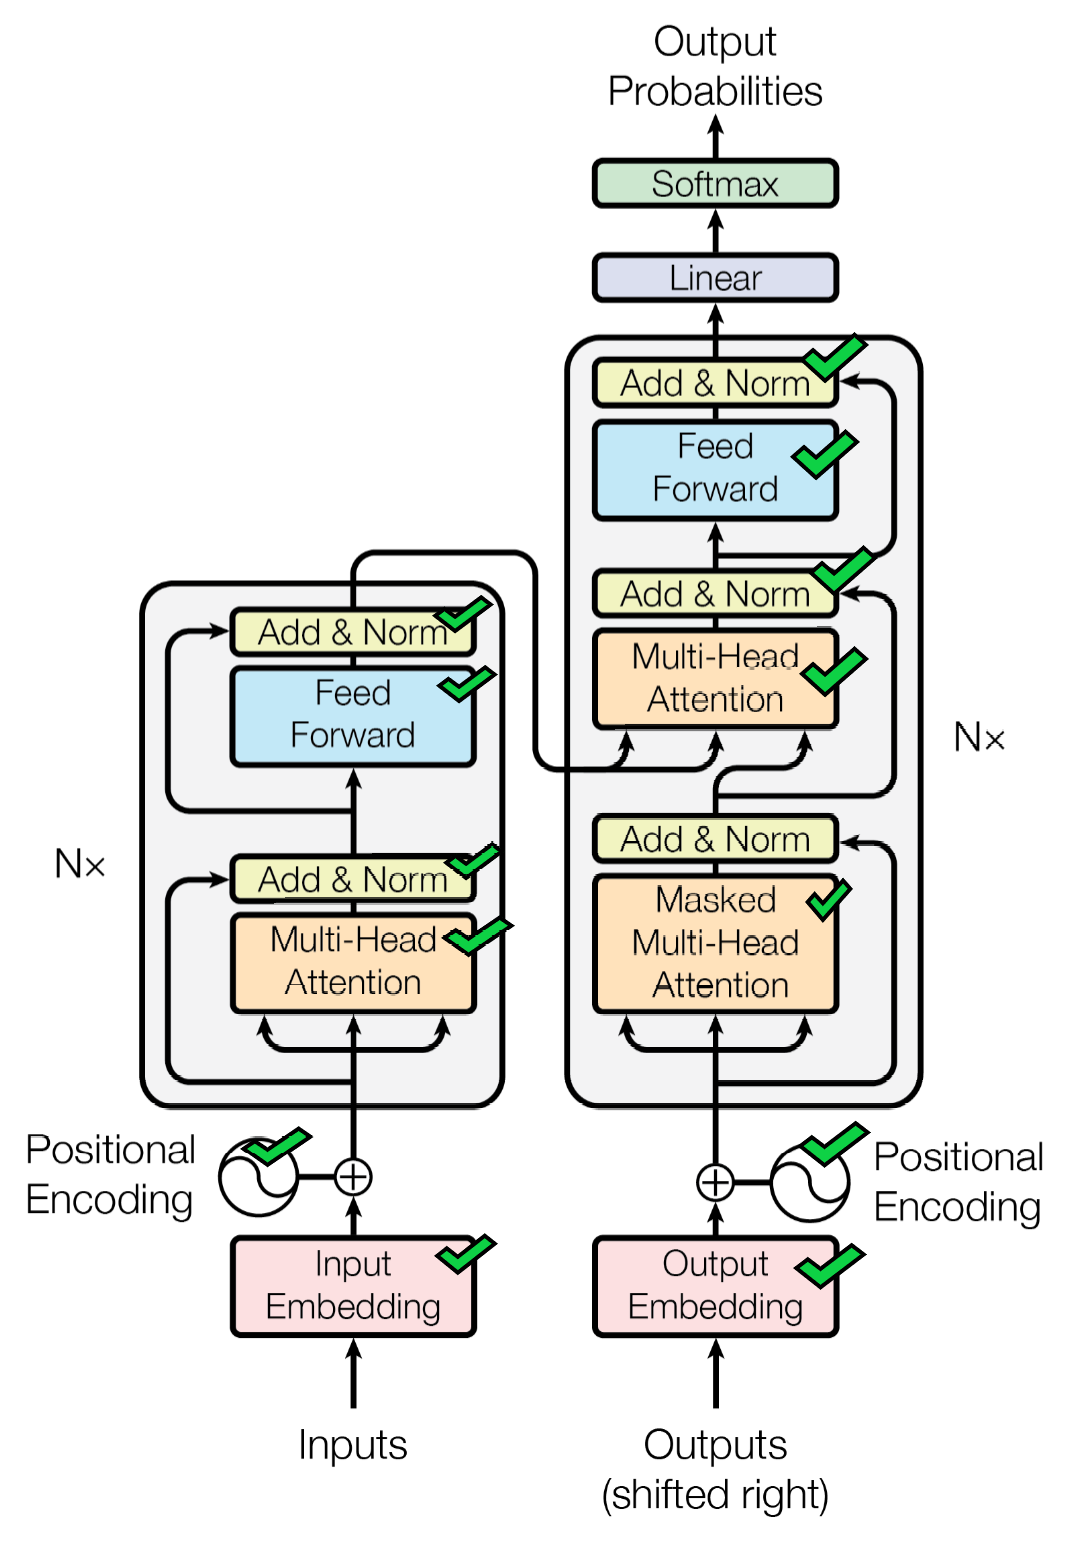

## 13. Construindo o Transformer completo

Agora podemos encaixar as peças.

### Encoder
- embedding
- positional encoding
- N blocos encoder

### Decoder
- embedding
- positional encoding
- N blocos decoder
- projeção para o vocabulário

Durante o treinamento, o decoder recebe a sequência alvo deslocada em uma posição (**teacher forcing**).

Durante a inferência, ele recebe um token por vez e continua gerando até produzir `<eos>`.

In [ ]:
class TinyTransformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=32,
        n_heads=4,
        d_ff=64,
        n_layers=2,
        max_len=20,
        dropout=0.0,
    ):
        super().__init__()

        # TODO armazene d_model.
        self.d_model = ...

        # TODO crie embeddings separados para tokens de origem e de destino.
        self.src_embedding = ...
        self.tgt_embedding = ...

        # TODO crie a codificação posicional usando max_len e d_model.
        self.position = ...

        # TODO crie n_layers blocos EncoderBlock usando d_model, n_heads,
        # d_ff e dropout.
        self.encoder_layers = ...

        # TODO crie n_layers blocos DecoderBlock usando d_model, n_heads,
        # d_ff e dropout.
        self.decoder_layers = ...

        # TODO crie LayerNorm final e uma projeção linear
        # de d_model para tgt_vocab_size.
        self.final_norm = ...
        self.output_projection = ...

    def encode(self, src, return_attention=False):
        # Embedding + informação de posição
        # TODO transforme os tokens de origem em embeddings e multiplique
        # por sqrt(d_model); depois adicione a informação posicional.
        x = ...
        x = ...

        # TODO crie uma lista vazia para armazenar as atenções do encoder.
        encoder_attentions = []

        # TODO percorra todas as camadas do encoder.
        for layer in self.encoder_layers:
            # TODO se return_attention=True, retorne também os pesos de atenção
            # da camada e armazene-os em encoder_attentions.
            if return_attention:
                x, attention = ...
                encoder_attentions.append(attention)
            else:
                x = ...

        return x, encoder_attentions

    def decode(self, tgt, memory, tgt_mask=None, return_attention=False):
        # Embedding + informação de posição
        # TODO transforme os tokens de destino em embeddings e adicione
        # a informação posicional.
        x = ...
        x = ...

        # TODO crie listas vazias para armazenar as atenções
        # de self-attention e cross-attention.
        self_attentions = []
        cross_attentions = []

        # TODO percorra todas as camadas do decoder.
        for layer in self.decoder_layers:
            # TODO se return_attention=True, obtenha e armazene
            # os dois tipos de atenção.
            if return_attention:
                x, self_attention, cross_attention = ...
                self_attentions.append(self_attention)
                cross_attentions.append(cross_attention)
            else:
                x = ...

        # TODO aplique LayerNorm e a projeção final para obter os logits.
        logits = ...

        return logits, self_attentions, cross_attentions

    def forward(self, src, tgt, tgt_mask=None, return_attention=False):
        # TODO execute o encoder usando src.
        memory, encoder_attentions = ...

        # TODO execute o decoder usando tgt, memory e tgt_mask.
        logits, self_attentions, cross_attentions = ...

        if return_attention:
            return logits, encoder_attentions, self_attentions, cross_attentions

        return logits

In [ ]:
# TODO crie o TinyTransformer usando o tamanho do vocabulário de itos
# para src_vocab_size e tgt_vocab_size.
# TODO use d_model=32, n_heads=4, d_ff=64, n_layers=2 e max_len=20.
model = ...

print(model)

## 14. Preparando os dados para treinamento

Para o decoder, usamos:

- `<bos>` = início da geração
- `<eos>` = fim da geração

No treinamento:

**entrada do decoder**

`<bos> o motor esta`

**alvo**

`o motor esta quente <eos>`

Isso implementa o teacher forcing: em cada posição, o modelo aprende a prever o próximo token.

In [ ]:
def encode_source(text):
    # Transformamos cada palavra da entrada em um ID
    ids = [stoi.get(token, stoi["<unk>"]) for token in text.split()]
    return torch.tensor([ids], dtype=torch.long)

In [ ]:
def encode_target(text):
    # O decoder começa com BOS e termina com EOS
    ids = [stoi["<bos>"]]
    ids.extend(stoi.get(token, stoi["<unk>"]) for token in text.split())
    ids.append(stoi["<eos>"])
    return torch.tensor([ids], dtype=torch.long)

In [ ]:
# Exemplo completo de teacher forcing
source_example = train_pairs[0][0]
target_example = train_pairs[0][1]

source_ids = encode_source(source_example)
target_ids = encode_target(target_example)

decoder_input = target_ids[:, :-1]
decoder_target = target_ids[:, 1:]

print("Entrada do encoder :", source_ids)
print("Entrada do decoder :", decoder_input)
print("Alvo               :", decoder_target)

print("\nDimensões:")
print("source_ids     :", source_ids.shape)
print("decoder_input  :", decoder_input.shape)
print("decoder_target :", decoder_target.shape)

## 15. Um forward pass antes do treinamento

Antes de treinar, os pesos ainda são essencialmente aleatórios.

Isso é importante pedagogicamente:

> **o Transformer não “sabe traduzir” porque construímos a arquitetura.**

A arquitetura fornece o mecanismo de processamento.

O comportamento aparece quando os parâmetros são ajustados pelo treinamento.

In [ ]:
# Montamos o batch de treinamento
src_batch = pad_sequence(
    [encode_source(source).squeeze(0) for source, _ in train_pairs],
    batch_first=True,
    padding_value=stoi["<pad>"]
)

target_batch = pad_sequence(
    [encode_target(target).squeeze(0) for _, target in train_pairs],
    batch_first=True,
    padding_value=stoi["<pad>"]
)

print("Source batch :", src_batch.shape)
print("Target batch :", target_batch.shape)

In [ ]:
# TODO remova o último token de target_batch para criar a entrada do decoder.
decoder_input_batch = ...
# TODO remova o primeiro token de target_batch para criar os rótulos esperados.
decoder_target_batch = ...
# TODO crie a função de perda CrossEntropyLoss().
loss_function = ...

# Fazemos um forward pass antes de qualquer atualização dos pesos
torch.manual_seed(SEED)

# TODO crie o TinyTransformer usando len(itos) para os vocabulários de origem
# e destino, d_model=32, n_heads=4, d_ff=64, n_layers=2 e max_len=20.
model = ...

# TODO crie a máscara causal usando o comprimento da sequência de entrada do decoder.
initial_mask = ...

# TODO faça um forward pass do modelo usando src_batch, decoder_input_batch
# e tgt_mask=initial_mask.
initial_logits = ...

# TODO calcule a loss comparando os logits com decoder_target_batch.
# TODO reorganize os logits e os alvos para o formato esperado pelo CrossEntropyLoss.
initial_loss = ...

print("Loss antes do treinamento:", round(initial_loss.item(), 4))
print("Shape dos logits:", initial_logits.shape)
initial_logits

## 16. Treinando o Transformer

O conjunto é minúsculo de propósito.

O objetivo não é construir um tradutor de produção, e sim observar o ciclo:

**entrada → Transformer → erro → backpropagation → atualização dos pesos → previsão melhor**

Como o problema é pequeno, conseguimos treinar rapidamente em CPU.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs = 300
loss_history = []

for epoch in range(num_epochs):
    model.train()

    optimizer.zero_grad()

    logits = model(
        src_batch,
        decoder_input_batch,
        tgt_mask=initial_mask
    )

    loss = loss_function(
        logits.reshape(-1, logits.size(-1)),
        decoder_target_batch.reshape(-1)
    )

    loss.backward()

    # Evitamos gradientes excessivamente grandes
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Época {epoch + 1:3d} | Loss: {loss.item():.6f}")

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Aprendizado do Transformer")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Loss inicial:", round(loss_history[0], 4))
print("Loss final  :", round(loss_history[-1], 6))

## 17. Inferência autoregressiva

Agora vem a mudança mais importante.

Durante o treinamento, o decoder recebe a resposta correta deslocada.

Durante a inferência, isso desaparece.

O modelo precisa fazer:

`<bos>`

→ prevê `o`

→ prevê `motor`

→ prevê `esta`

→ prevê `quente`

→ prevê `<eos>`

Ou seja:

> **cada nova previsão depende do que o modelo já gerou.**

In [ ]:
def decode_greedy(model, source_text, max_new_tokens=8, return_attention=False):
    # Colocamos o modelo em modo de avaliação
    model.eval()

    source_ids = encode_source(source_text)
    generated_ids = torch.tensor(
        [[stoi["<bos>"]]],
        dtype=torch.long
    )

    attention_rows = []
    confidences = []

    for _ in range(max_new_tokens):
        # A máscara cresce junto com a sequência gerada
        target_mask = causal_mask(generated_ids.size(1))

        with torch.no_grad():
            if return_attention:
                logits, _, _, cross_attentions = model(
                    source_ids,
                    generated_ids,
                    tgt_mask=target_mask,
                    return_attention=True
                )

                # Guardamos a última linha da cross-attention da última camada
                last_attention = cross_attentions[-1][0, 0, -1].cpu().numpy()
            else:
                logits = model(
                    source_ids,
                    generated_ids,
                    tgt_mask=target_mask
                )

        # Pegamos a distribuição do último token e escolhemos o maior valor
        probabilities = F.softmax(logits[:, -1, :], dim=-1)
        confidence, next_id = probabilities.max(dim=-1)

        next_id = next_id.item()
        confidence = confidence.item()

        confidences.append(confidence)

        if return_attention:
            attention_rows.append(last_attention)

        generated_ids = torch.cat(
            [generated_ids, torch.tensor([[next_id]])],
            dim=1
        )

        if next_id == stoi["<eos>"]:
            break

    generated_tokens = [
        itos[idx]
        for idx in generated_ids.squeeze(0).tolist()
    ]

    return generated_tokens, attention_rows, confidences

In [ ]:
# Testamos uma frase que não estava no conjunto de treinamento
example_source = test_pairs[0][0]
example_target = test_pairs[0][1]

generated_tokens, attention_rows, confidences = decode_greedy(
    model,
    example_source,
    return_attention=True
)

print("Entrada :", example_source)
print("Esperado:", example_target)
print("Gerado  :", " ".join(
    token for token in generated_tokens
    if token not in {"<bos>", "<eos>"}
))

## 18. Avaliando o conjunto de teste

O teste abaixo usa combinações de objeto + estado que não estavam presentes no treinamento.

Isso deixa a aula um pouco mais interessante do que simplesmente memorizar cada frase.

In [ ]:
def clean_generated_tokens(tokens):
    return [
        token
        for token in tokens
        if token not in {"<bos>", "<eos>", "<pad>"}
    ]


correct = 0

for source, target, in test_pairs:
    generated, _, _ = decode_greedy(
        model,
        source,
        return_attention=False
    )

    prediction = " ".join(clean_generated_tokens(generated))

    print(f"Entrada : {source}")
    print(f"Alvo    : {target}")
    print(f"Modelo  : {prediction}")
    print(f"Acertou : {prediction == target}")
    print("-" * 70)

    if prediction == target:
        correct += 1

accuracy = correct / len(test_pairs)

print(f"Acurácia exata no conjunto de teste: {accuracy:.1%}")

## 19. O que o Transformer está fazendo durante a inferência?

Vamos parar em um único exemplo e abrir a “caixa” novamente.

Queremos observar simultaneamente:

1. a entrada;
2. os tokens gerados;
3. a confiança em cada token;
4. a **cross-attention** entre saída e entrada.

Essa é uma das visualizações mais úteis para conectar a arquitetura matemática com o comportamento observável do modelo.

In [ ]:
final_source = test_pairs[0][0]
final_target = test_pairs[0][1]

final_tokens, final_attention_rows, final_confidences = decode_greedy(
    model,
    final_source,
    return_attention=True
)

source_tokens = final_source.split()
generated_clean = clean_generated_tokens(final_tokens)

print("=" * 80)
print("RESULTADO FINAL")
print("=" * 80)
print(f"Entrada : {final_source}")
print(f"Alvo    : {final_target}")
print(f"Modelo  : {' '.join(generated_clean)}")
print("=" * 80)

print("\nConfiança por token:")
for token, confidence in zip(generated_clean, final_confidences):
    print(f"{token:12s} -> {confidence:.3f}")

In [ ]:
# Montamos uma matriz de atenção: uma linha por token gerado
attention_matrix = np.array(final_attention_rows)
attention_labels = generated_clean + ["<eos>"][:max(0, len(final_attention_rows) - len(generated_clean))]

# Ajustamos os rótulos quando EOS apareceu na geração
generated_with_eos = [
    token for token in final_tokens[1:]
    if token != "<bos>"
]

if len(generated_with_eos) == len(final_attention_rows):
    attention_labels = generated_with_eos

plt.figure(figsize=(9, 5))
sns.heatmap(
    attention_matrix,
    xticklabels=source_tokens,
    yticklabels=attention_labels,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1
)
plt.xlabel("Tokens da entrada — encoder")
plt.ylabel("Tokens considerados pelo decoder")
plt.title("Cross-attention durante a inferência")
plt.tight_layout()
plt.show()

print(
    "\nObserve especialmente o token final da tradução. "
    "O modelo tende a concentrar atenção nas posições da entrada que ajudam a produzi-lo."
)

- Ao gerar “o”, o decoder dá maior atenção a “is” (0.62).
- Ao gerar “esta”, concentra mais atenção em “engine” (0.56).
- Ao gerar “ocupado”, concentra fortemente a atenção em “busy” (0.82).
- Ao gerar <eos>, a maior atenção está em “engine” (0.94).

### Referências

- Vaswani et al. — *Attention Is All You Need* (2017)
- Jay Alammar — *The Illustrated Transformer*
- Notebook-base fornecido para esta aula: implementação de Transformer from scratch em PyTorch
